In [ ]:
# ===============================
# SaaS Product Analytics Dashboard
# Exploratory Data Analysis
# ===============================

# Author: Shelly Resurreccion
# Purpose: Exploratory data analysis of synthetic saas user data to identify patterns and key predictive features.

# Requirements
# pip install pandas numpy matplotlib seaborn

In [2]:
# =====================================================
# Import libraries
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set(style='whitegrid')

In [3]:
# =====================================================
# Load synthetic dataset
# =====================================================
data = pd.read_csv('../00_data/synthetic_saas_user_data.csv', parse_dates=['signup_date', 'last_active_date'])
print("Dataset shape:", data.shape)
data.head()


Dataset shape: (500, 9)


,user_id,signup_date,last_active_date,plan_type,num_logins,num_features_used,avg_session_length,region,churned
0,1001,2021-04-13,2021-04-25,basic,14,7,10.8,APAC,True
1,1002,2022-03-12,2022-08-09,basic,19,10,12.8,APAC,True
2,1003,2021-09-28,2022-03-01,basic,18,1,7.8,EU,True
3,1004,2021-04-17,2021-07-14,basic,16,9,6.2,APAC,True
4,1005,2021-03-13,2021-08-14,basic,13,8,9.3,EU,True


In [4]:
# =====================================================
# Basic EDA
# =====================================================
# Summary statistics
print(data.describe(include='all'))

            user_id                 signup_date            last_active_date  \
count    500.000000                         500                         500   
unique          NaN                         NaN                         NaN   
top             NaN                         NaN                         NaN   
freq            NaN                         NaN                         NaN   
mean    1250.500000  2022-01-03 21:24:28.800000  2022-04-01 15:56:09.600000   
min     1001.000000         2021-01-02 00:00:00         2021-01-14 00:00:00   
25%     1125.750000         2021-07-02 06:00:00         2021-09-25 12:00:00   
50%     1250.500000         2022-01-11 00:00:00         2022-04-05 00:00:00   
75%     1375.250000         2022-07-17 00:00:00         2022-10-02 06:00:00   
max     1500.000000         2022-12-31 00:00:00         2023-10-15 00:00:00   
std      144.481833                         NaN                         NaN   

       plan_type  num_logins  num_features_used  av

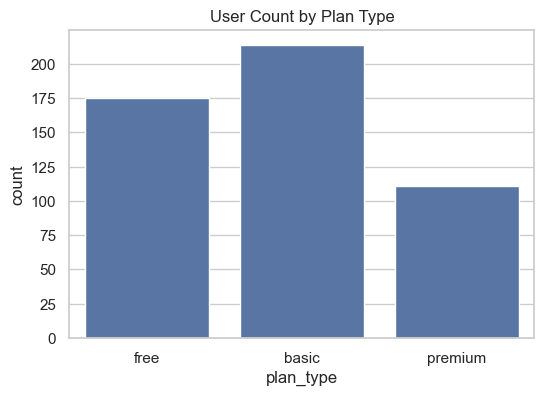

In [5]:
# Distribution of subscription plans
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='plan_type', order=['free','basic','premium'])
plt.title('User Count by Plan Type')
plt.show()

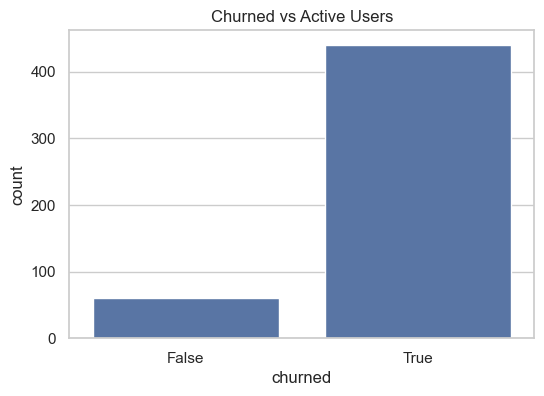

In [6]:
# Churn distribution
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='churned')
plt.title('Churned vs Active Users')
plt.show()

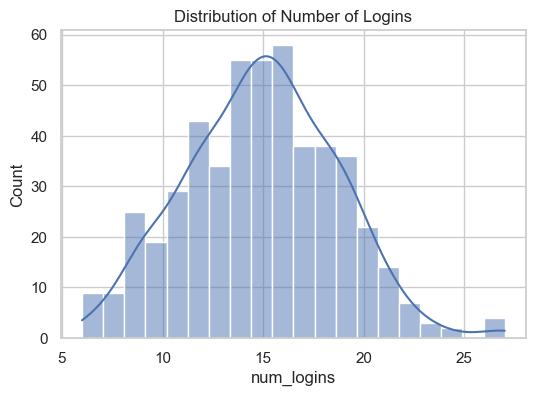

In [7]:
# Distribution of logins
plt.figure(figsize=(6,4))
sns.histplot(data['num_logins'], bins=20, kde=True)
plt.title('Distribution of Number of Logins')
plt.show()


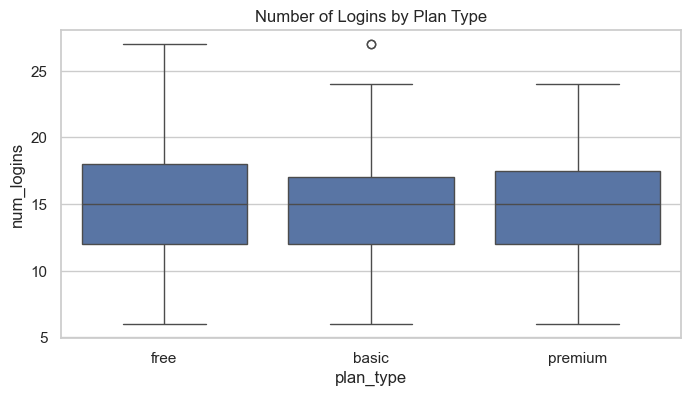

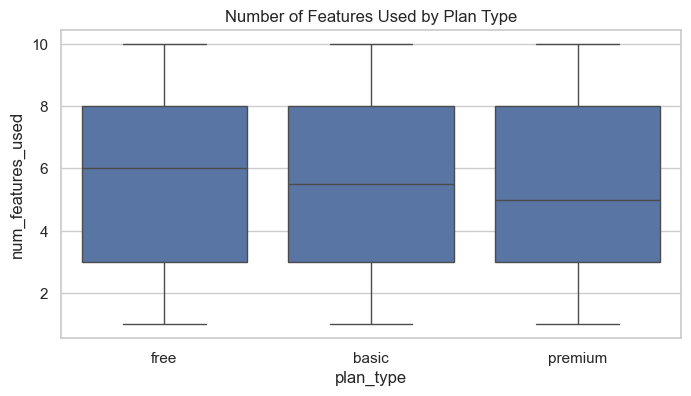

In [8]:
# =====================================================
# Engagement vs Plan Type
# =====================================================
plt.figure(figsize=(8,4))
sns.boxplot(x='plan_type', y='num_logins', data=data, order=['free','basic','premium'])
plt.title('Number of Logins by Plan Type')
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x='plan_type', y='num_features_used', data=data, order=['free','basic','premium'])
plt.title('Number of Features Used by Plan Type')
plt.show()

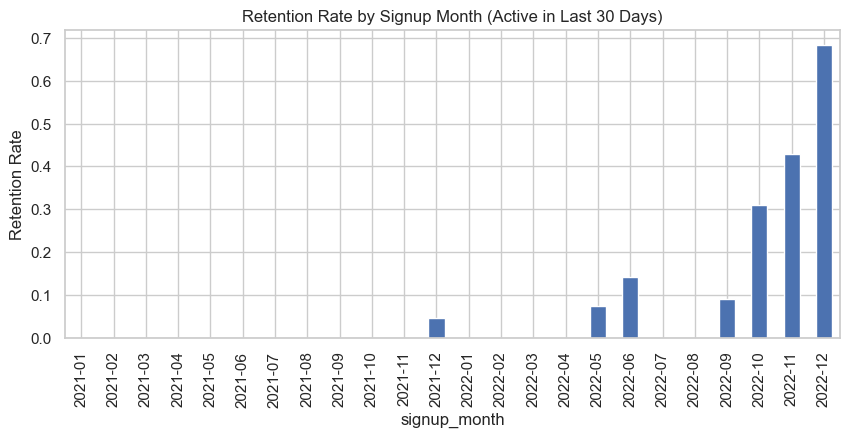

In [9]:
# =====================================================
# Cohort Retention Analysis
# =====================================================
# Define cohort month
data['signup_month'] = data['signup_date'].dt.to_period('M')

# Calculate days since signup
today = pd.to_datetime('2023-03-01')
data['days_since_signup'] = (today - data['signup_date']).dt.days

# Retention flag: active in last 30 days
data['retained_last_30_days'] = data['last_active_date'] > (today - pd.Timedelta(days=30))

# Retention rate by signup month
retention = data.groupby('signup_month')['retained_last_30_days'].mean()
retention.plot(kind='bar', figsize=(10,4))
plt.ylabel('Retention Rate')
plt.title('Retention Rate by Signup Month (Active in Last 30 Days)')
plt.show()

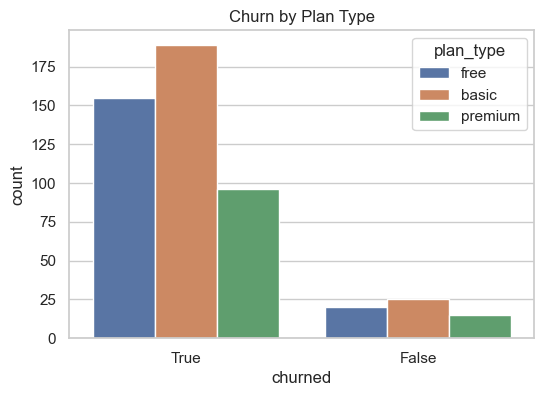

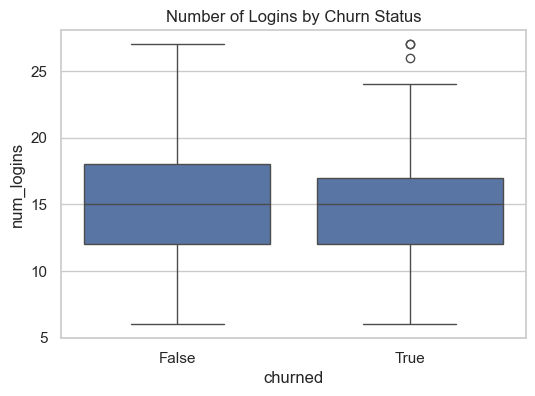

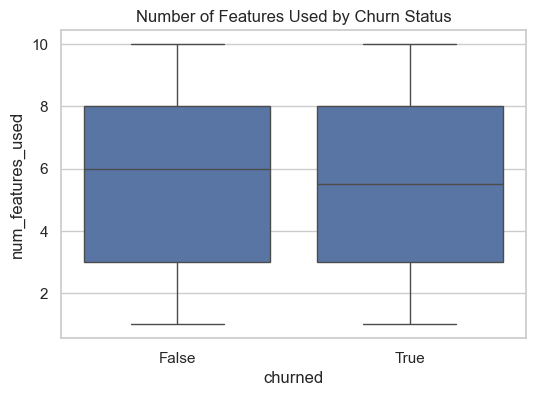

In [10]:
# =====================================================
# Churn Analysis
# =====================================================
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='churned', hue='plan_type', order=[True, False])
plt.title('Churn by Plan Type')
plt.show()

# Churn vs Engagement
plt.figure(figsize=(6,4))
sns.boxplot(x='churned', y='num_logins', data=data)
plt.title('Number of Logins by Churn Status')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='churned', y='num_features_used', data=data)
plt.title('Number of Features Used by Churn Status')
plt.show()

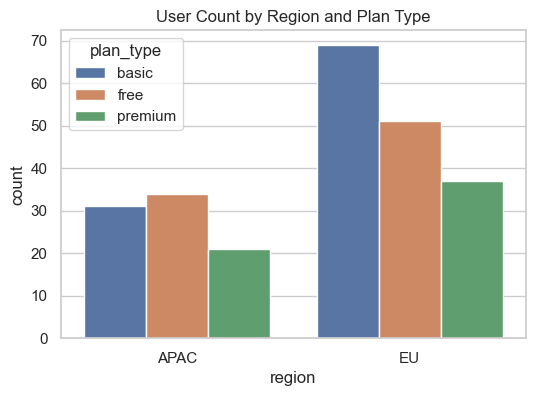

/var/folders/39/m2n3qgr96q700lmqw2r65zbh0000gn/T/ipykernel_15849/2242424462.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=data, x='region', y='avg_session_length', ci=None)


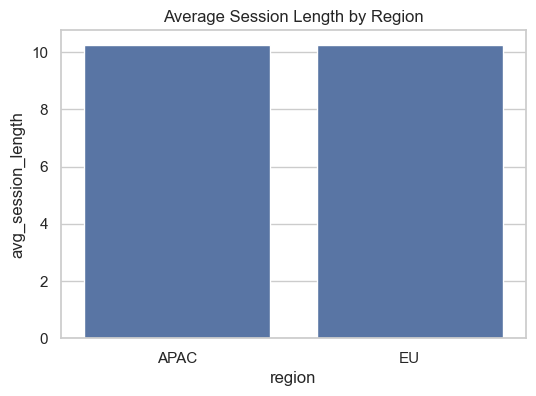

In [11]:
# =====================================================
# Regional Analysis
# =====================================================
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='region', hue='plan_type')
plt.title('User Count by Region and Plan Type')
plt.show()

# Average session length by region
plt.figure(figsize=(6,4))
sns.barplot(data=data, x='region', y='avg_session_length', ci=None)
plt.title('Average Session Length by Region')
plt.show()

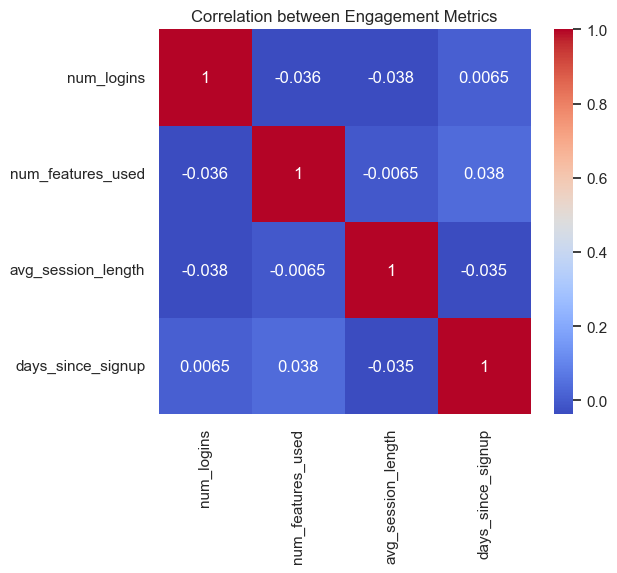

In [12]:
# =====================================================
# Feature Correlation
# =====================================================
numerical_cols = ['num_logins', 'num_features_used', 'avg_session_length', 'days_since_signup']
plt.figure(figsize=(6,5))
sns.heatmap(data[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between Engagement Metrics')
plt.show()